# **STINTSY MCO**
## De La Salle University
### Authors
- Ian De Jesus
- Jeff Valerio Fonte
- Ponj Elazegui
- Raine Villaver
### Date: March 21, 2026

### Repository:
- https://github.com/saxzeee/STINTSY-MCO

---
## **Table Of Contents** 
1. [Introduction](#introduction)
   - [Dataset Description](#dataset-description)
   - [Required Libraries](#required-libraries)
   - [Reading the Dataset](#reading-the-dataset)
   - [Reviewing the Values of Each Feature](#reviewing-the-values-of-each-feature)
3. [Model Selection](#model-selection)
4. [Data Preparation](#data-preparation)
5. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis)
6. [Data Preprocessing](#data-preprocessing)
7. [Model Training](#model-training)
8.  [Error Analysis](#error-analysis)
9.  [Model Tuning](#model-tuning)
10. [Model Evaluation](#model-evaluation)
11. [Insights and Conclusions](#insights-and-conclusions)
12. [References](#references)

---
## **Introduction**
---

### Dataset Description  

The dataset used in this project is loaded from [`Dataset.csv`](https://raw.githubusercontent.com/rainev/Bean_Dataset/refs/heads/main/Dataset.csv). It contains 13,610 bean samples, where each row represents one dry bean instance described by 16 numerical features and 1 target label.

The numerical attributes capture image-derived size and shape measurements such as `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `Eccentricity`, `ConvexArea`, `EquivDiameter`, `Solidity`, `roundness`, `Compactness`, and the `ShapeFactor` variables. The target column, `Class`, identifies the bean variety.

There are 7 bean classes in the dataset: `BARBUNYA`, `BOMBAY`, `CALI`, `DERMASON`, `HOROZ`, `SEKER`, and `SIRA`. This makes the dataset suitable for supervised multiclass classification and exploratory analysis of morphological differences between bean varieties.

**Table 1** <br>
Summary of Features
<table>
    <tr>
        <th>#</th>
        <th>Variable</th>
        <th>Description</th>
        <th>Range/Levels</th>
    </tr>
    <tr>
        <td>1</td>
        <td>Area</td>
        <td>The area of a bean zone and the number of pixels within its boundaries.</td>
        <td>20420 - 254616</td>
    </tr>
    <tr>
        <td>2</td>
        <td>Perimeter</td>
        <td>Bean circumference is defined as the length of its border.</td>
        <td>524.73 - 1985.37</td>
    </tr>
        <tr>
        <td>3</td>
        <td>MajorAxisLength</td>
        <td>The distance between the ends of the longest line that can be drawn from a bean.</td>
        <td>183.60 - 738.86</td>
    </tr>
    <tr>
        <td>4</td>
        <td>MinorAxisLength</td>
        <td>The longest line that can be drawn from the bean while standing perpendicular to the main axis.</td>
        <td>122.51 - 460.19</td>
    </tr>
    <tr>
        <td>5</td>
        <td>AspectRatio</td>
        <td>Defines the relationship between MajorAxisLength and MinorAxisLength.</td>
        <td>1.0248 - 2.4303</td>
    </tr>
    <tr>
        <td>6</td>
        <td>Eccentricity</td>
        <td>Eccentricity of the ellipse having the same moments as the region.</td>
        <td>0.2189 - 0.9114</td>
    </tr>
        <tr>
        <td>7</td>
        <td>ConvexArea</td>
        <td>Number of pixels in the smallest convex polygon that can contain the area of a bean seed.</td>
        <td>20684 - 263261</td>
    </tr>
    <tr>
        <td>8</td>
        <td>EquivDiameter</td>
        <td>Equivalent diameter: The diameter of a circle having the same area as a bean seed area.</td>
        <td>161.24 - 569.37</td>
    </tr>
    <tr>
        <td>9</td>
        <td>Extent</td>
        <td>The ratio of the pixels in the bounding box to the bean area.</td>
        <td>0.5553 - 0.8661</td>
    </tr>
    <tr>
        <td>10</td>
        <td>Solidity</td>
        <td>Also known as convexity. The ratio of the pixels in the convex shell to those found in beans.</td>
        <td>0.9192 - 0.9946</td>
    </tr>
    <tr>
        <td>11</td>
        <td>roundness</td>
        <td>Calculated with the following formula: (4piA)/(P^2).</td>
        <td>0.4896 - 0.9906</td>
    </tr>
    <tr>
        <td>12</td>
        <td>Compactness</td>
        <td>Measures the roundness of an object: Ed/L</td>
        <td>0.6405 - 0.9873</td>
    </tr>
    <tr>
        <td>13</td>
        <td>ShapeFactor1</td>
        <td></td>
        <td>0.0027 - 0.0104</td>
    </tr>
    <tr>
        <td>14</td>
        <td>ShapeFactor2</td>
        <td></td>
        <td>0.0005 - 0.0036</td>
    </tr>
    <tr>
        <td>15</td>
        <td>ShapeFactor3</td>
        <td></td>
        <td>0.4103 - 0.9747</td>
    </tr>
    <tr>
        <td>16</td>
        <td>ShapeFactor4</td>
        <td></td>
        <td>0.9476 - 0.9997</td>
    </tr>
    <tr>
        <td>17</td>
        <td>Class</td>
        <td>Type of bean.</td>
        <td> [1] BARBUNYA <br>
             [2] BOMBAY <br>
             [3] CALI <br>
             [4] DERMASON <br>
             [5] HOROZ <br>
             [6] SEKER <br>
             [7] SIRA             
        </td>
    </tr>
</table>

### Required Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Reading the Dataset

The dataset is retrieved from a CSV file hosted on the project's [GitHub repository](https://github.com/rainev/Bean_Dataset/tree/main). We use the `pandas.read_csv` function to load the data into a DataFrame object named `df`. This DataFrame will be used for further analysis throughout this project.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/rainev/Bean_Dataset/refs/heads/main/Dataset.csv')

The `info()` function displays general information about the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

### Reviewing the Values of Each Feature
We review the unique values of each column in the dataset to gain an initial understanding of its contents. This step helps in identifying potential inconsistencies, such as repeated values or unexpected categories, and ensures that the data is as expected before moving on to further analysis or cleaning.

In [4]:
with np.printoptions(threshold=75):
    for col in df.columns:
        print(f"Unique values for column '{col}':")
        print(np.sort(df[col].unique()))            
        print("=" * 50)

Unique values for column 'Area':
[ 20420  20464  20548 ... 248424 251432 254616]
Unique values for column 'Perimeter':
[ 524.736  524.932  525.413 ... 1919.868 1921.685 1985.37 ]
Unique values for column 'MajorAxisLength':
[183.601165  183.9652515 185.3819214 ... 726.3734932 738.1445017
 738.8601535]
Unique values for column 'MinorAxisLength':
[122.5126535 129.5762069 129.7481935 ... 449.3396784 450.9261867
 460.1984968]
Unique values for column 'AspectRation':
[1.0248676  1.03642268 1.0419637  ... 2.38739489 2.38887344 2.43030645]
Unique values for column 'Eccentricity':
[0.21895126 0.26277438 0.28093659 ... 0.90804778 0.90816732 0.91142297]
Unique values for column 'ConvexArea':
[ 20684  20772  20825 ... 251082 257425 263261]
Unique values for column 'EquivDiameter':
[161.2437642 161.4173908 161.7483421 ... 562.4084465 565.8031152
 569.3743583]
Unique values for column 'Extent':
[0.55531472 0.56666925 0.56676753 ... 0.85284143 0.85841985 0.86619464]
Unique values for column 'Solidity

In [5]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [6]:
df['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

---
## **Model Selection**
In this notebook, we aim to predict the bean type with the use of three machine learning models: K-Nearest Neighbors, Multinomial Logistic Regression, and Neural Networks. The dataset has 7 labels which requires these models that are suitable for multiclass classification tasks. 
### 1. K-Nearest Neigbors
KNN is simple and effective for this problem as it makes predictions based on the similarity of feature values. This algorithm fits our dataset as it makes predictions based on distance metrics, where it can group similar beans together and assign their respective labels. Moreover, the model's performance can be easily tuned by adjusting the number of neighbors. 
### 2. Multinomial Logistic Regression
Multinomial Logistic Regression is designed for multiclass classification problems, which naturally fits our objectives. 
### 3. Neural Networks
Nueral Networks are a flexible model for learning relationships between features and labels, which is ideal for predicting bean types. 

---
## **Data Preparation**

In [7]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


#### Checking for Duplicate Rows

The dataset is also checked for duplicate rows to identify repeated observations. Duplicate entries may bias the model, so they should be removed when necessary.

In [8]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
68


#### Removing Duplicate Rows

If duplicate rows are found, they are removed to improve the quality and consistency of the dataset.

In [9]:
df = df.drop_duplicates()

#### Checking for Malformed Data Entry and Line-Ending Issues

Before modeling, the target labels are checked for hidden spaces or carriage-return characters that may create inconsistent class names. The `Class` column is cleaned in place using `str.strip()` so that only one standardized target column is kept for the rest of the workflow.

In [10]:
print("Raw unique classes: ", df["Class"].nunique())

Raw unique classes:  7


In [11]:
df["Class"] = df["Class"].astype(str).str.strip()

In [12]:
print("Cleaned unique classes:", df["Class"].nunique())
print(df["Class"].value_counts())

Cleaned unique classes: 7
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


#### Separating Features and Target Variable

The predictor variables are separated from the target variable. In this dataset, the input features are the numerical bean measurements, while the target variable is the cleaned `Class` column. Removing only `Class` from `X` prevents the target labels from being included as model inputs.

In [13]:
X = df.drop("Class", axis=1)
y = df["Class"]

#### Encoding the Target Variable

Since the target variable contains categorical labels, it must be converted into numerical form so that machine learning algorithms can process it.

In [14]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

#### Splitting the Dataset

The dataset is divided into training and testing sets. This allows the model to learn from one portion of the data and be evaluated on a separate unseen portion.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

#### Scaling the Features

Feature scaling is applied so that all numerical variables are placed on a comparable scale. This is especially useful for models that are sensitive to differences in feature magnitude.

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Viewing the Processed Data Shapes

The shapes of the training and testing sets are displayed to confirm that the preprocessing steps were completed successfully.

In [17]:
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (10834, 16)
Testing set shape: (2709, 16)


---

## **Exploratory Data Analysis**

This section aims to provide a better understanding of the data through visualizations and summary statistics, exploring distributions and identifying relationships between variables.

We begin by examining the distribution of bean samples across classes. This helps determine whether the dataset is balanced and highlights which classes may be underrepresented during model training.

C:\Users\ejohn\AppData\Local\Temp\ipykernel_16872\2916469144.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")


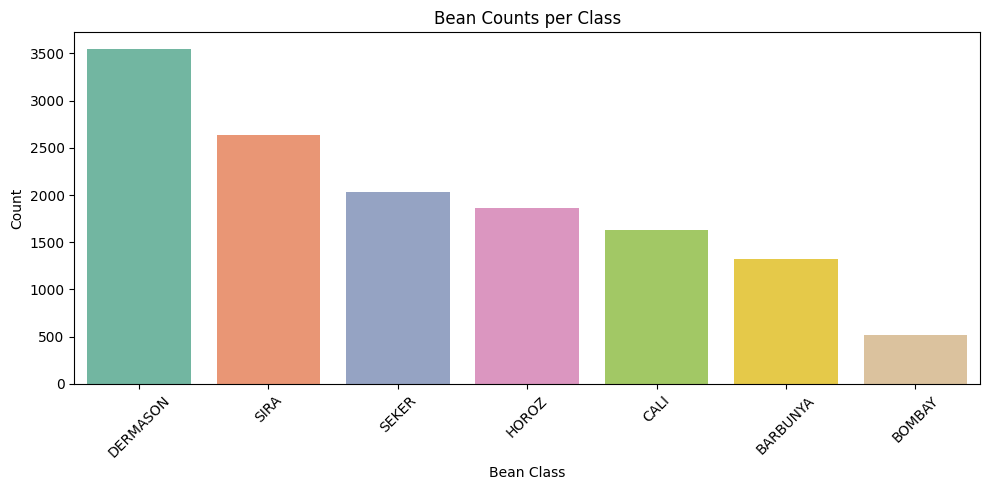

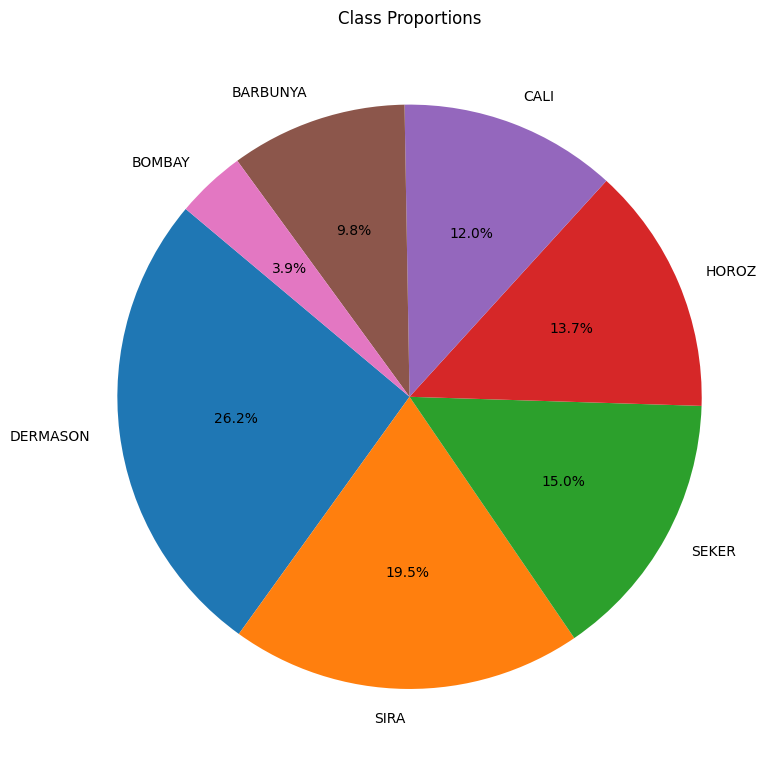

In [18]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated and will be removed in a future version.*",
    category=FutureWarning
)

class_counts = df["Class"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")
plt.title("Bean Counts per Class")
plt.xlabel("Bean Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Class Proportions")
plt.tight_layout()
plt.show()

#### Interpretation of Class Distribution

The bar chart and pie chart show that the dataset is not balanced across bean classes. `DERMASON` has the largest number of samples, while `BOMBAY` has the smallest. This class imbalance should be considered during model development, since models may perform better on majority classes than on minority classes if evaluation is based only on overall accuracy.

#### Distribution of Key Bean Features

To better understand the physical characteristics of the beans, we examine the distributions of seven important continuous features: `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `Eccentricity`, `roundness`, and `Compactness`.

Histograms are used to see how values are spread across the whole dataset, including where values are concentrated and whether the distribution is skewed. Density plots provide a smoother view of the same overall distribution, making peaks and tails easier to notice. Boxplots grouped by `Class` are included to compare the same feature across bean varieties, helping identify differences in median values, variability, and potential outliers.

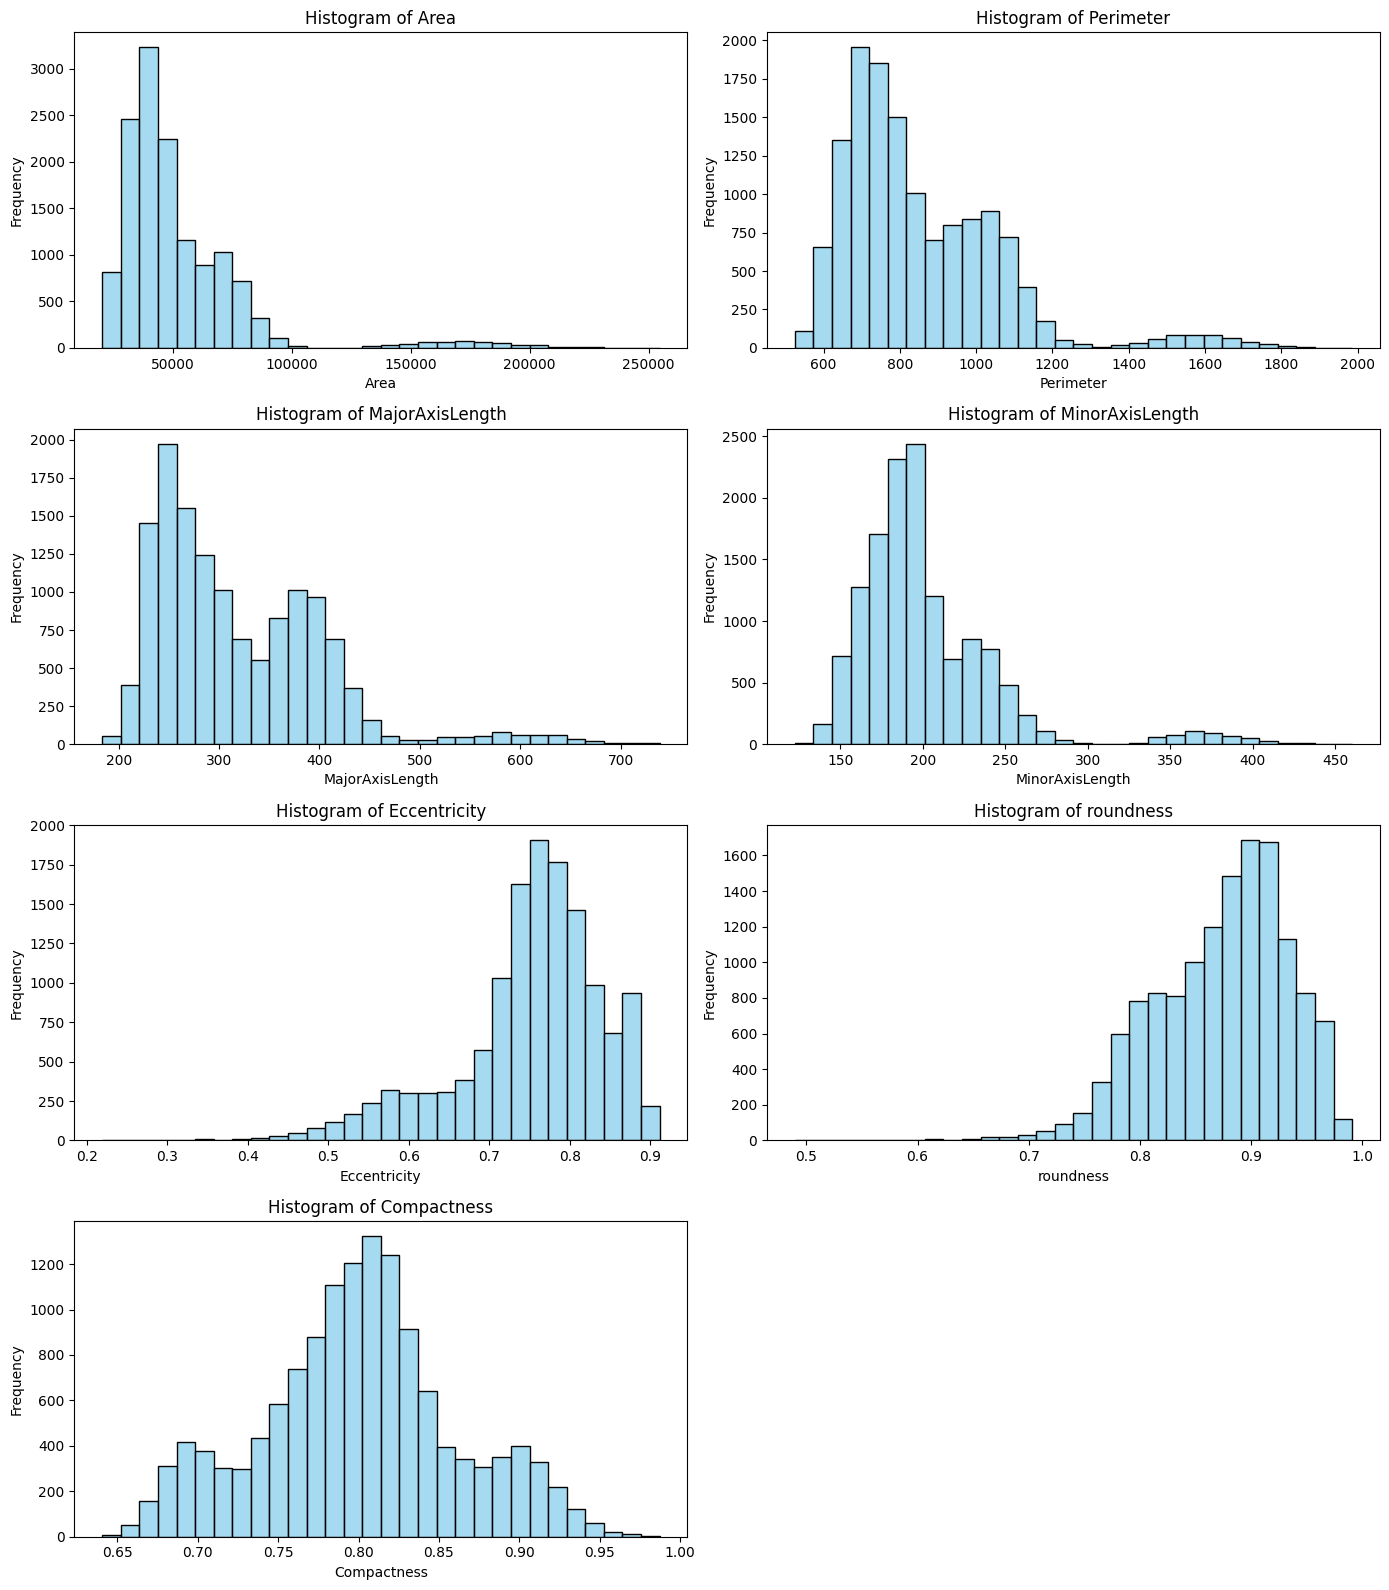

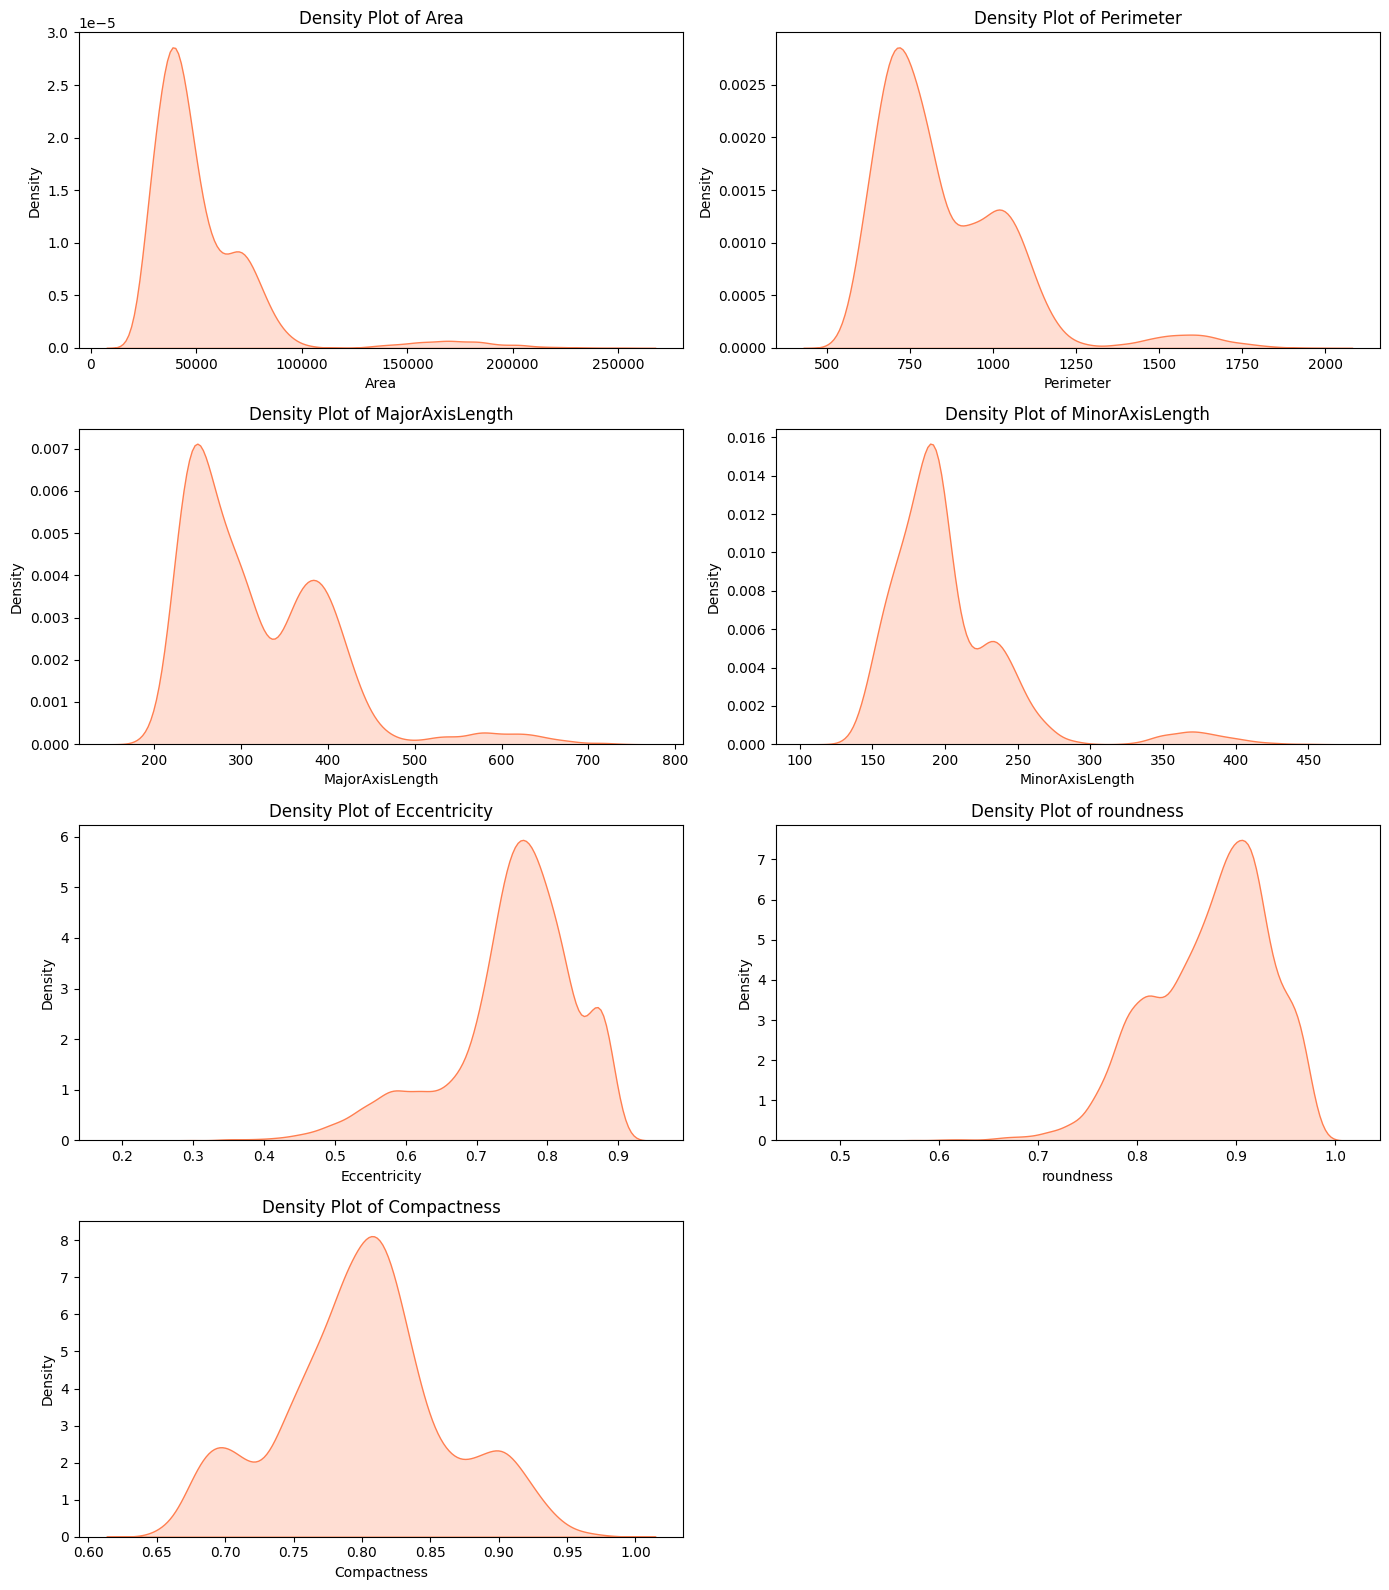

C:\Users\ejohn\AppData\Local\Temp\ipykernel_16872\3868254163.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=feature, order=class_order, ax=axes[i], palette="Set3")
C:\Users\ejohn\AppData\Local\Temp\ipykernel_16872\3868254163.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=feature, order=class_order, ax=axes[i], palette="Set3")
C:\Users\ejohn\AppData\Local\Temp\ipykernel_16872\3868254163.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=feature, order=class_order,

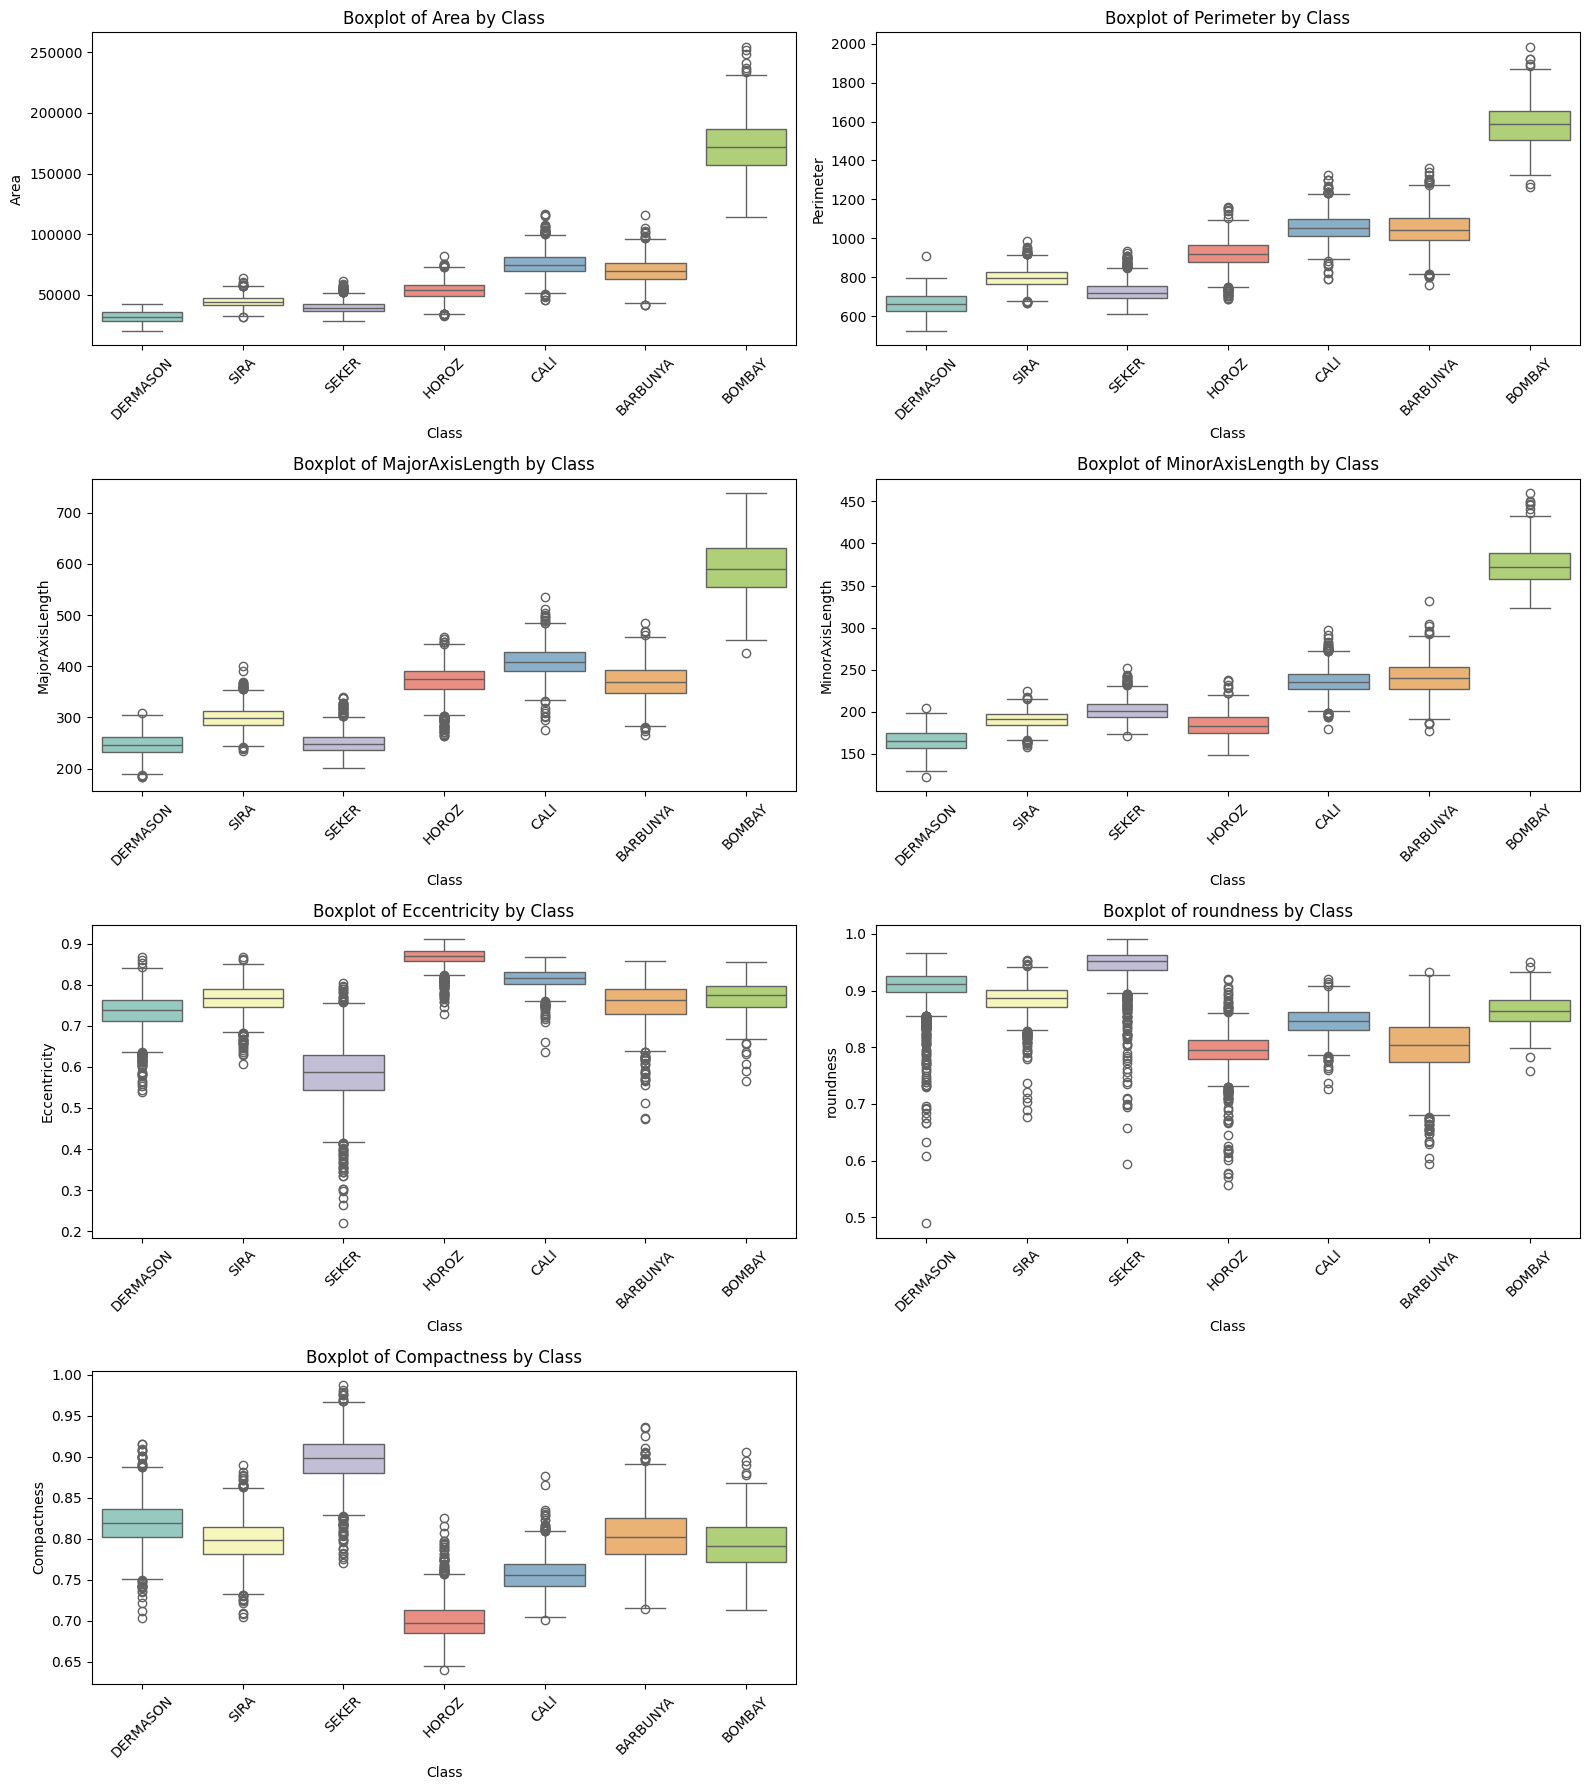

In [19]:
feature_columns = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "Eccentricity",
    "roundness",
    "Compactness"
]

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated and will be removed in a future version.*",
    category=FutureWarning
)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):
    sns.histplot(df[feature], bins=30, kde=False, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Histogram of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):
    sns.kdeplot(data=df, x=feature, fill=True, ax=axes[i], color="coral")
    axes[i].set_title(f"Density Plot of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
axes = axes.flatten()

class_order = df["Class"].value_counts().index

for i, feature in enumerate(feature_columns):
    sns.boxplot(data=df, x="Class", y=feature, order=class_order, ax=axes[i], palette="Set3")
    axes[i].set_title(f"Boxplot of {feature} by Class")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis="x", rotation=45)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

#### Interpretation of Feature Distributions

The histograms and density plots summarize the overall behavior of each numerical feature across all bean samples. These plots are useful for understanding the general shape of the data before building models, such as whether a feature has a wide range, clusters around certain values, or appears skewed.

The boxplots are more useful for class comparison because they show how each feature differs across bean classes. Features such as `Area`, `Perimeter`, `MajorAxisLength`, and `MinorAxisLength` are expected to show clearer separation because they directly describe bean size. Shape-related measures such as `Eccentricity`, `roundness`, and `Compactness` can reveal differences in bean form, which may also contribute to class discrimination.

#### Correlation Between Numerical Features

After examining the individual feature distributions, the next step is to study how the numerical features relate to one another. A correlation heatmap helps identify strongly related variables, which is useful for understanding redundancy among measurements and for interpreting which bean properties tend to increase or decrease together.

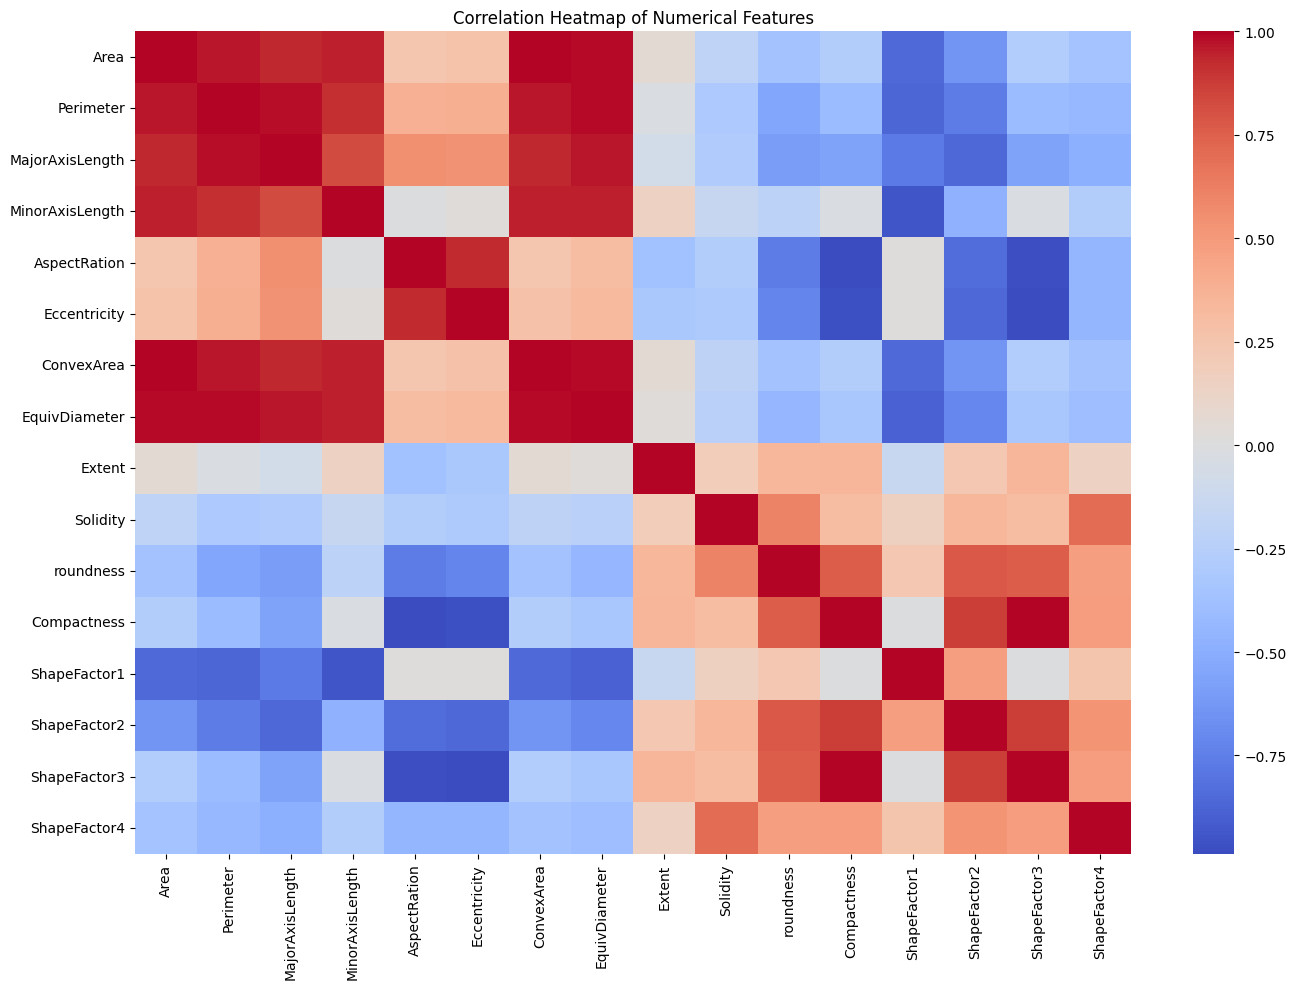

In [20]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.drop(columns=["Class"]).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

#### Interpretation of Correlation Heatmap

The correlation heatmap shows the strength and direction of relationships between pairs of numerical features. Strong positive correlations suggest that some measurements capture similar information, especially among size-related variables such as `Area`, `Perimeter`, and the axis lengths. This is useful in EDA because it shows which features move together and which ones may provide distinct information for classification.

#### Scatter Plots for Class Separation

Scatter plots are used to examine how pairs of features interact while showing the bean class through color. Unlike the earlier histograms and density plots, these visualizations make it easier to see whether certain bean varieties form visible clusters or overlap with one another in feature space.

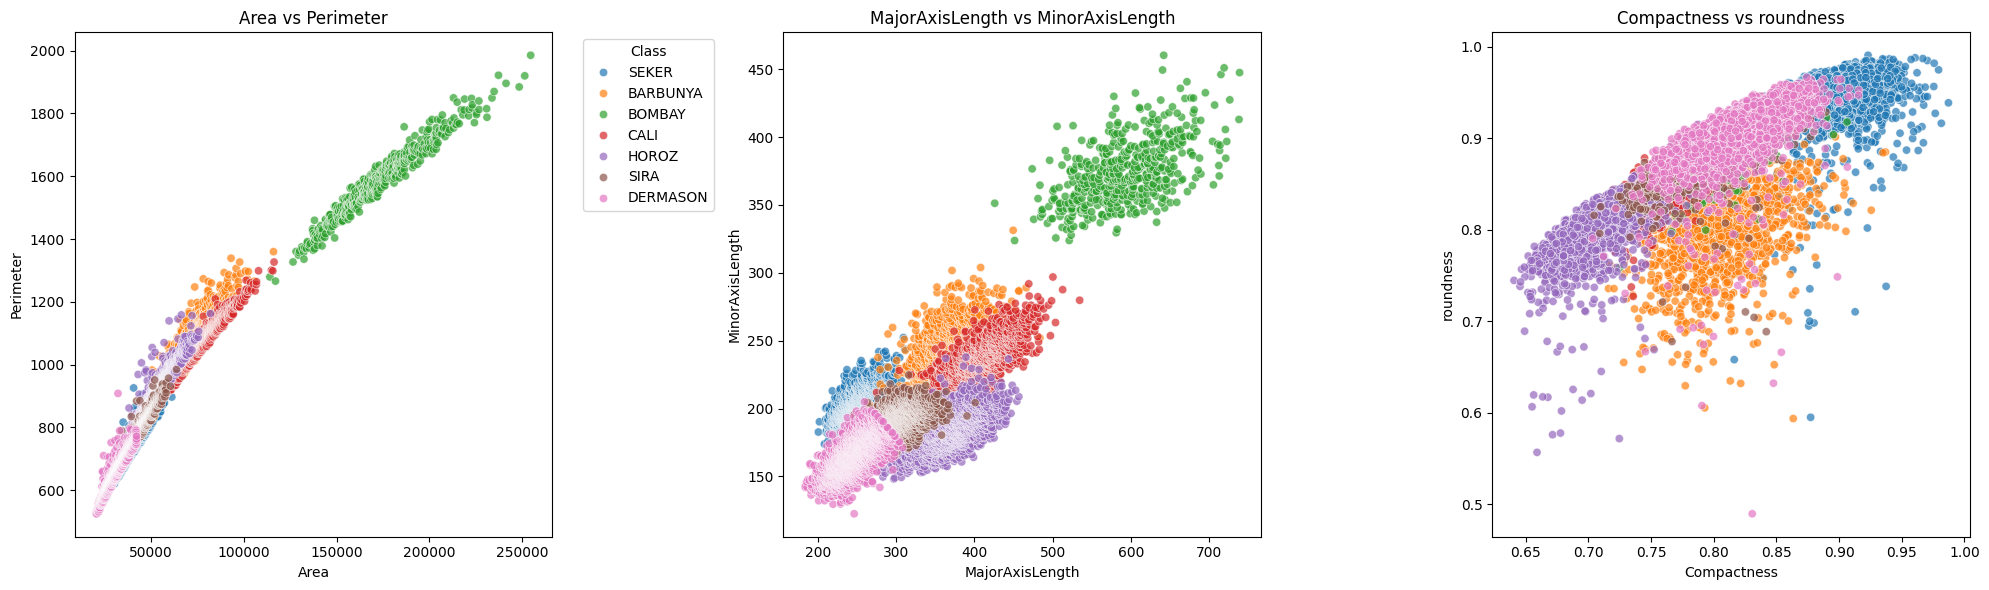

In [21]:
scatter_pairs = [
    ("Area", "Perimeter"),
    ("MajorAxisLength", "MinorAxisLength"),
    ("Compactness", "roundness")
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (x_feature, y_feature) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue="Class",
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f"{x_feature} vs {y_feature}")
    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")

for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

#### Interpretation of Scatter Plots

These scatter plots help assess class separability by showing whether bean classes cluster in different regions when two features are considered together. Pairs such as `Area` and `Perimeter`, or `MajorAxisLength` and `MinorAxisLength`, are especially useful because they combine related size measurements. If classes show visible grouping, these features are likely to be informative for the classification models that follow.

#### Violin Plots by Class

This visualization compares the distribution of the features: `Area`, `Perimeter`, `AspectRation`, and `Compactness` with the various bean classes. Each violin shows the density of values within a class, inclusing the meidan and quartiles. It allows us to view the skewness, spread, and patterns for each bean class.

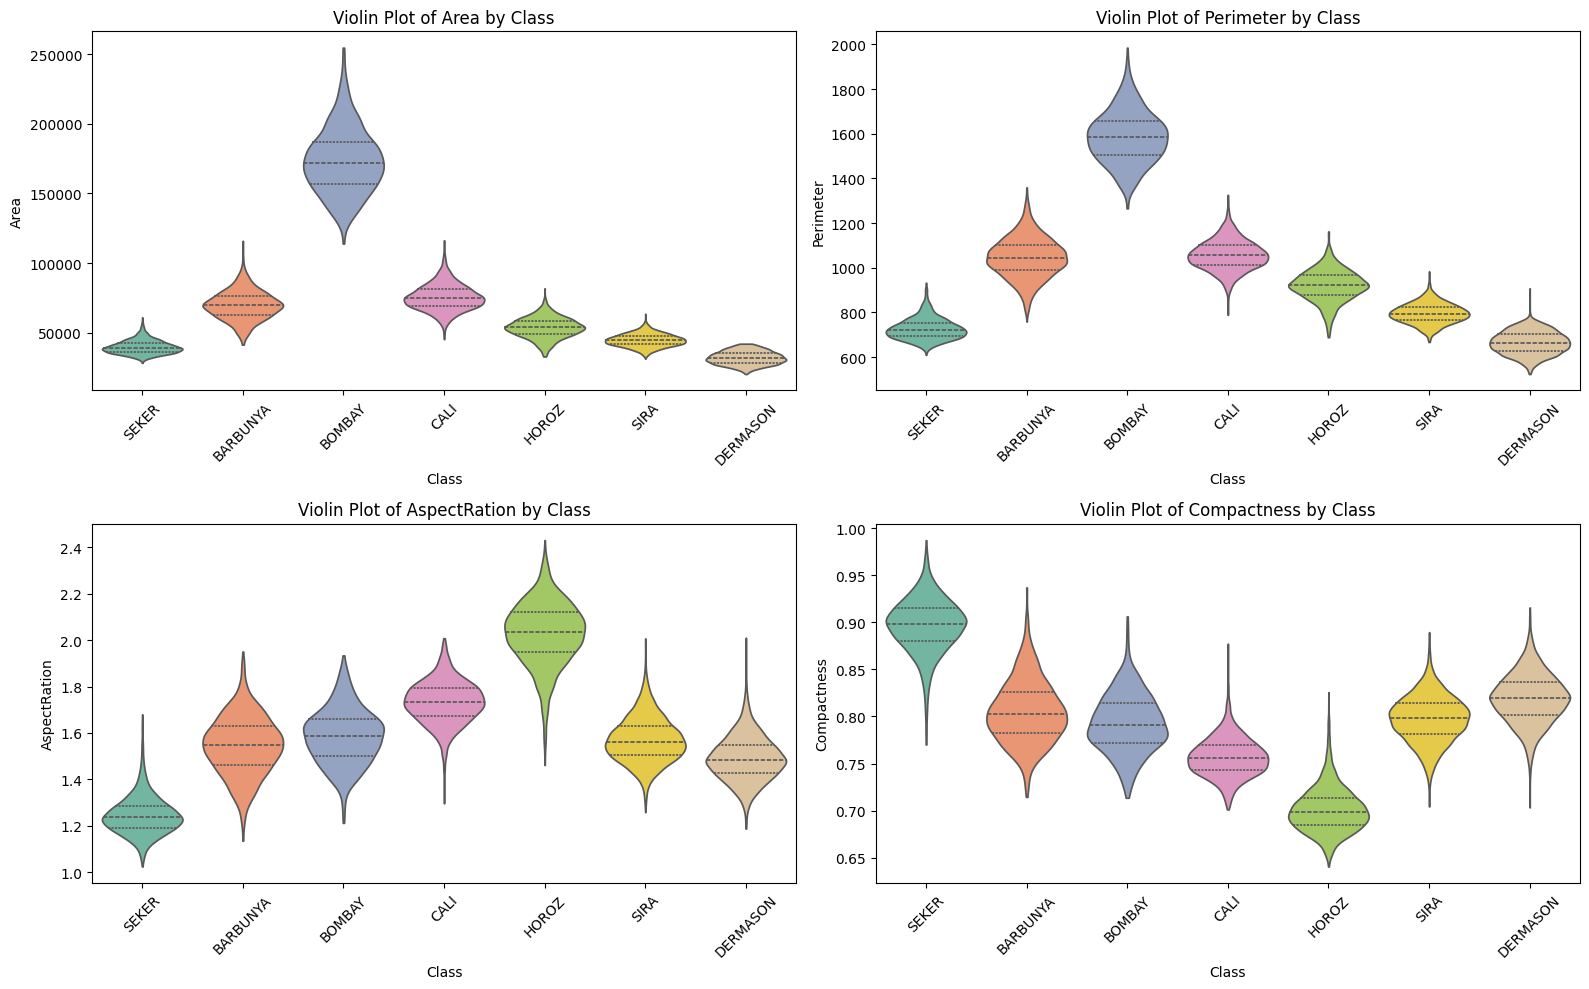

In [22]:
violin_features = ["Area", "Perimeter", "AspectRation", "Compactness"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, violin_features):
    sns.violinplot(
        data=df,
        x="Class",
        y=feature,
        hue="Class",
        legend=False,
        ax=ax,
        inner="quartile",
        cut=0,
        palette="Set2"
    )
    ax.set_title(f"Violin Plot of {feature} by Class")
    ax.set_xlabel("Class")
    ax.set_ylabel(feature)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Interpretation of Violin Plots

The violin plots show the class differences in both size and shape-related attributes. `BOMBAY` is larger in area/perimeter, `HOROZ` is larger in aspect ratio, and `SEKER` is larger in compactness. It reveals that `Area` and `Perimeter` indicate the most distinct class differences, while Aspect Ratio shows more subtle variations. `Compactness` doesn't show much clear class differences compared to the other features.

#### Normalized Feature Heatmap

This heatmap displays the mean values of each feature for each bean type after normalization. The rows represent the bean classes, while the columns represent the features. The intensity indicates whether a value is above or below the mean.

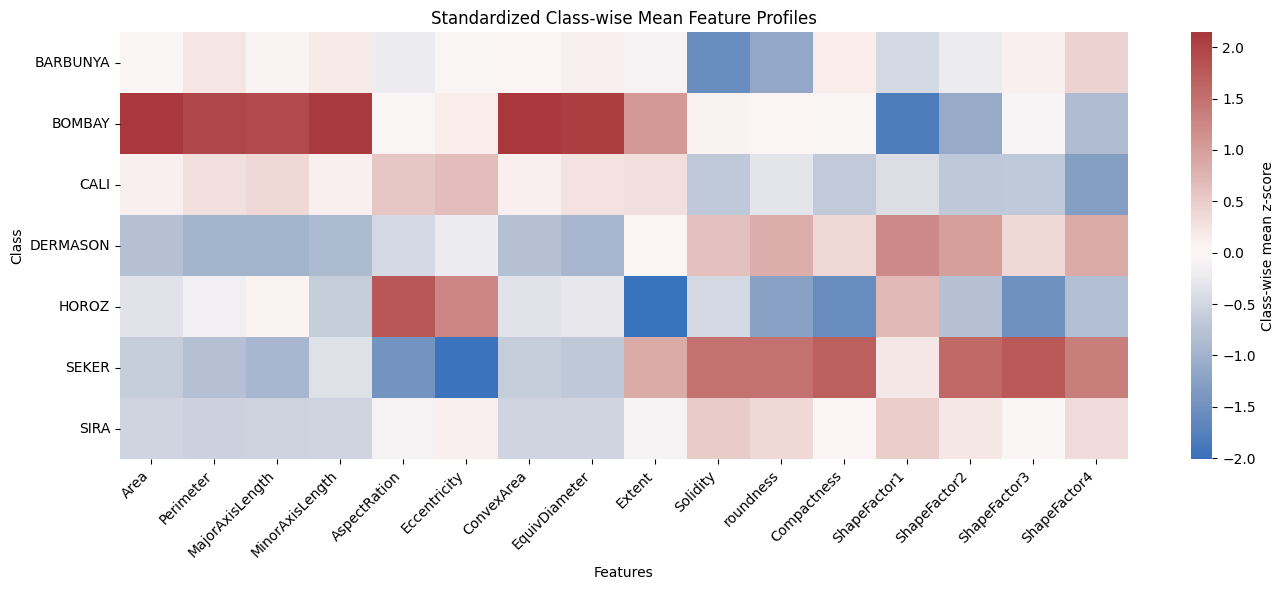

In [23]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
class_feature_means = df.groupby("Class")[numeric_cols].mean()
class_feature_z = (class_feature_means - class_feature_means.mean()) / class_feature_means.std()

plt.figure(figsize=(14, 6))
sns.heatmap(class_feature_z, cmap="vlag", center=0, cbar_kws={"label": "Class-wise mean z-score"})
plt.title("Standardized Class-wise Mean Feature Profiles")
plt.xlabel("Features")
plt.ylabel("Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Interpretation of Class-wise Feature Heatmap

The heatmap shows that `BOMBAY` has consistently high values in size-related features, which suggests that it is larger than the other bean types. Meanwhile, `DERMASON` and `SEKER` are smaller due to their lower values. Moreover, some classes such as `CALI` and `SIRA` are more balanced. This visualization helps us understand that beans have unique combinations of size and shape characteristics that can be used to differentiate them.

#### Pairplot (Sampled Data)

The pairplot visualizes the pairwise relationships among the features `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, and `Compactness` across different bean classes. It allows us to explore relationships, correlations, and class distincitions in one visaulization. Sampling is used to reduce the number of points for better visibility.

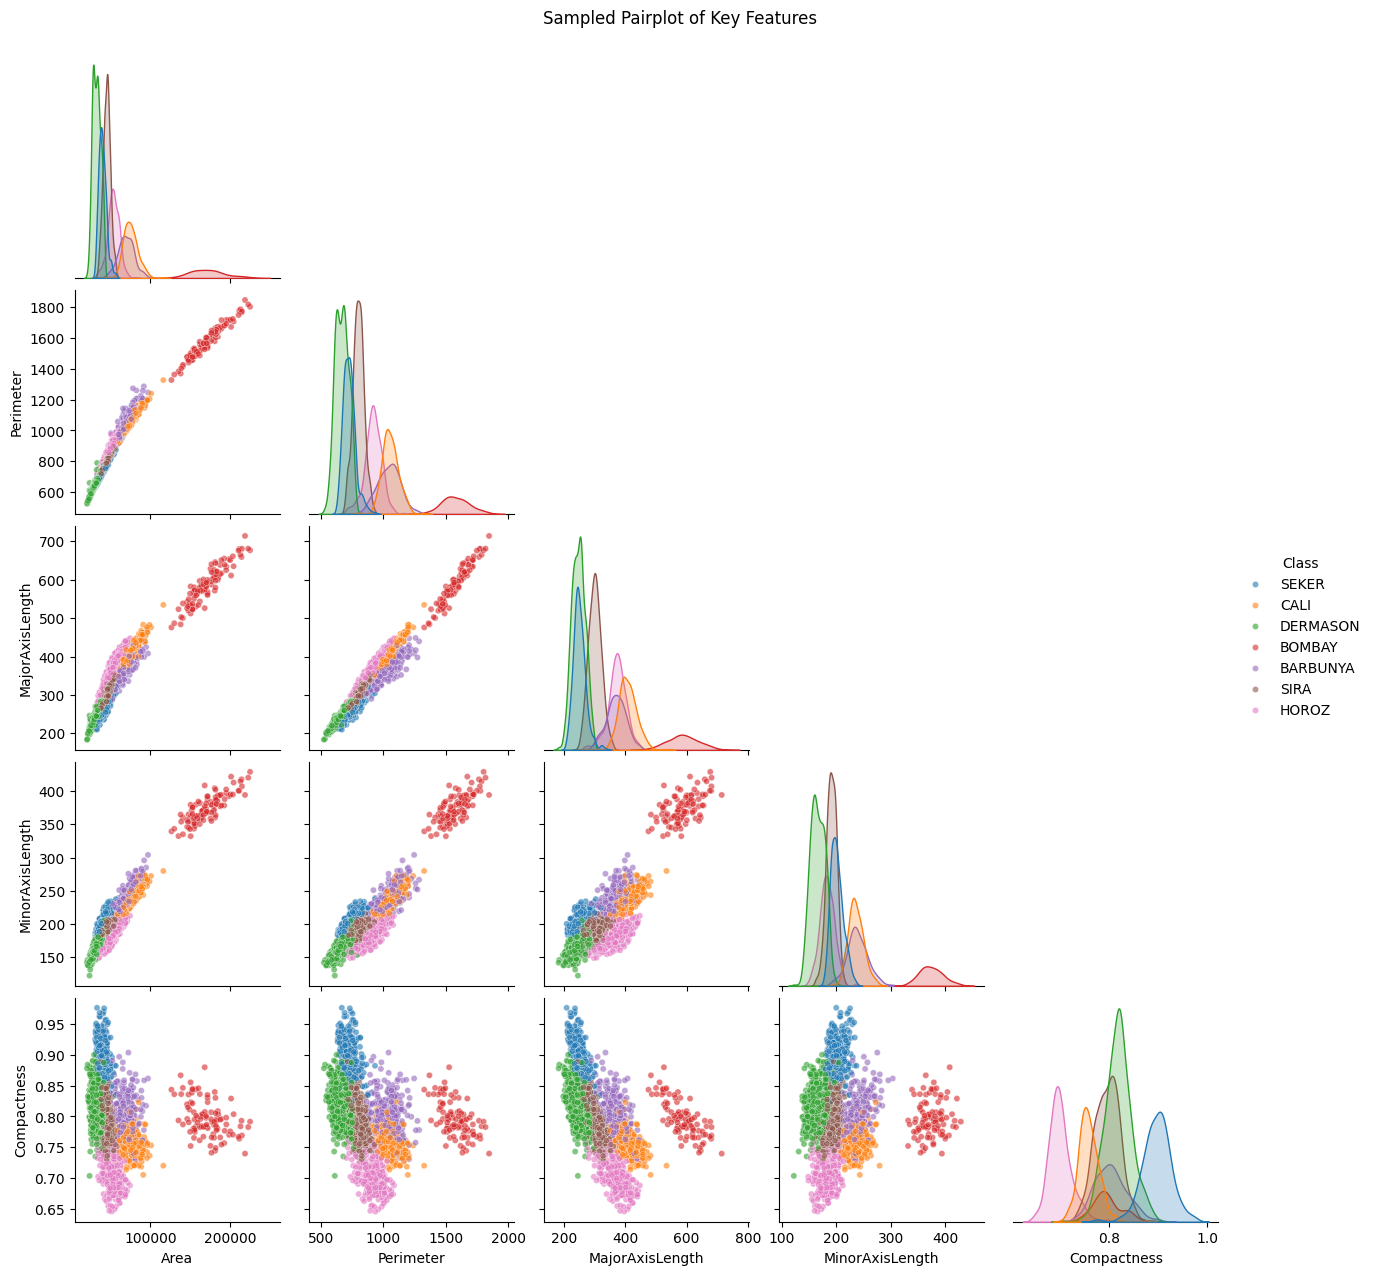

In [24]:
pairplot_features = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "Compactness", "Class"]
pairplot_sample = df[pairplot_features].sample(n=min(2500, len(df)), random_state=42)
sns.pairplot(
    pairplot_sample,
    hue="Class",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20}
 )
plt.suptitle("Sampled Pairplot of Key Features", y=1.02)
plt.show()

#### Interpretation of Pairplot

The pairplot shows strong positive correlations among size-related features such as `Area`, `Perimeter`, `MajorAxisLength`, and `MinorAxisLength`. While  `Compactness` is less correlated with these size features. `BOMBAY` is clearly separated due to its larger size, while other classes overlap but still show distinct clusters. 

---
## **Data Preprocessing**

---
## **Model Training**

The three chosen models are trained separately in this section using the scaled training data prepared earlier. Each subsection briefly describes the role of the model, fits it to the training data, and records its training and testing accuracy for later comparison.

#### Training Setup

A shared dictionary is initialized to store the fitted models, together with a list that will collect the performance of each classifier. This keeps the outputs organized and makes the later evaluation sections easier to build.

In [25]:
trained_models = {}
training_results = []

### 1. K-Nearest Neighbors

K-Nearest Neighbors classifies each bean by comparing it with the most similar samples in the training set. Because the method depends on distance, the scaled feature values prepared earlier are used directly for fitting and prediction.

In [26]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

trained_models["K-Nearest Neighbors"] = knn_model

knn_train_predictions = knn_model.predict(X_train_scaled)
knn_test_predictions = knn_model.predict(X_test_scaled)

training_results.append({
    "Model": "K-Nearest Neighbors",
    "Train Accuracy": accuracy_score(y_train, knn_train_predictions),
    "Test Accuracy": accuracy_score(y_test, knn_test_predictions)
})

C:\Users\ejohn\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ejohn\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateP

### 2. Multinomial Logistic Regression

Multinomial Logistic Regression is a linear classification model designed for problems with more than two classes. It estimates the probability of each bean belonging to one of the seven categories, then selects the class with the highest probability.

In [27]:
logreg_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
logreg_model.fit(X_train_scaled, y_train)

trained_models["Multinomial Logistic Regression"] = logreg_model

logreg_train_predictions = logreg_model.predict(X_train_scaled)
logreg_test_predictions = logreg_model.predict(X_test_scaled)

training_results.append({
    "Model": "Multinomial Logistic Regression",
    "Train Accuracy": accuracy_score(y_train, logreg_train_predictions),
    "Test Accuracy": accuracy_score(y_test, logreg_test_predictions)
})

C:\Users\ejohn\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 3. Neural Network

The neural network model can learn more complex nonlinear relationships between the bean measurements and the class labels. A small multilayer perceptron is used here as an initial baseline architecture for multiclass classification.

In [28]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_train_scaled, y_train)

trained_models["Neural Network"] = mlp_model

mlp_train_predictions = mlp_model.predict(X_train_scaled)
mlp_test_predictions = mlp_model.predict(X_test_scaled)

training_results.append({
    "Model": "Neural Network",
    "Train Accuracy": accuracy_score(y_train, mlp_train_predictions),
    "Test Accuracy": accuracy_score(y_test, mlp_test_predictions)
})

#### Training Summary

After fitting all three models, their training and testing accuracies are collected into a single table. This summary provides a quick comparison of overall performance before moving into deeper error analysis and tuning.

In [29]:
training_results_df = pd.DataFrame(training_results).sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

training_results_df.style.format({
    "Train Accuracy": "{:.4f}",
    "Test Accuracy": "{:.4f}"
})

,Model,Train Accuracy,Test Accuracy
0,Neural Network,0.9475,0.9251
1,Multinomial Logistic Regression,0.9262,0.9195
2,K-Nearest Neighbors,0.9424,0.9155


---
## **Error Analysis**

This section analyzes the mistakes each trained model makes when tested. The types of beans the models predict correctly, and the beans they tend to mix up, are shown using classification reports and confusion matrices. Moreover, this section is also to show and help us understand where the models are struggling before doing any tuning. 

### 1. K-Nearest Neighbors Error Analysis

The KNN model is evaluated first to inspect how a distance-based classifier behaves across the seven bean categories.

,precision,recall,f1-score,support
BARBUNYA,0.931727,0.875472,0.902724,265.000000
BOMBAY,1.000000,1.000000,1.000000,104.000000
CALI,0.898256,0.947853,0.922388,326.000000
DERMASON,0.915134,0.912553,0.913842,709.000000
HOROZ,0.961219,0.932796,0.946794,372.000000
SEKER,0.947631,0.935961,0.941760,406.000000
SIRA,0.848987,0.874763,0.861682,527.000000
accuracy,0.915467,0.915467,0.915467,0.915467
macro avg,0.928993,0.925628,0.927027,2709.000000
weighted avg,0.916315,0.915467,0.915652,2709.000000


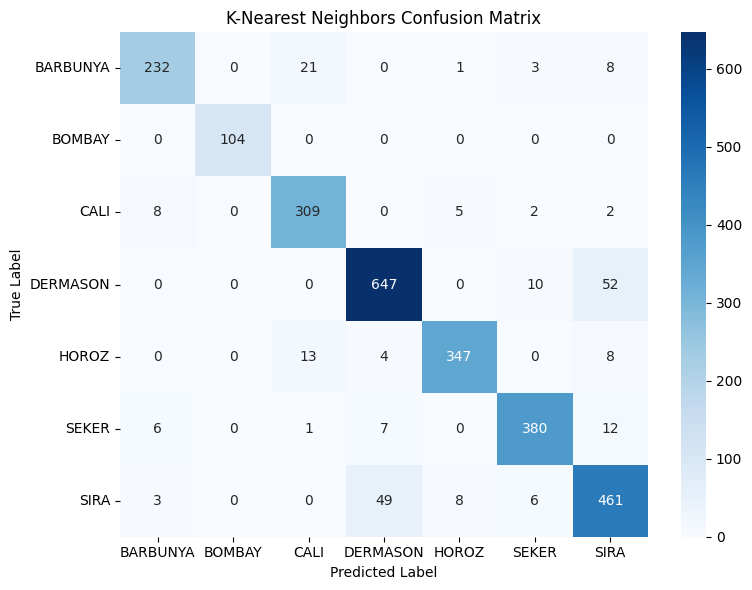

In [30]:
knn_report = pd.DataFrame(
    classification_report(
        y_test,
        knn_test_predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )
).transpose()

display(knn_report)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, knn_test_predictions),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("K-Nearest Neighbors Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**Interpretation**
- SIRA is the most confusing class which is often confused with DERMASON, occasionally with HOROZ and SEKER. This means that these beans share similar characteristics. 
- BARBUNYA and CALI are occasionally mixed up, showing some feature overlap.
- BOMBAY is perfectly classified, meaning it’s very distinct from the others.
- Since KNN relies on similarity, it struggles when classes are close together in the feature space.

### 2. Multinomial Logistic Regression Error Analysis

The logistic regression model is then reviewed to see how well a linear decision boundary separates the bean classes.

,precision,recall,f1-score,support
BARBUNYA,0.925490,0.890566,0.907692,265.000000
BOMBAY,1.000000,1.000000,1.000000,104.000000
CALI,0.910979,0.941718,0.926094,326.000000
DERMASON,0.926513,0.906911,0.916607,709.000000
HOROZ,0.964286,0.943548,0.953804,372.000000
SEKER,0.931873,0.943350,0.937576,406.000000
SIRA,0.858456,0.886148,0.872082,527.000000
accuracy,0.919528,0.919528,0.919528,0.919528
macro avg,0.931085,0.930320,0.930551,2709.000000
weighted avg,0.920116,0.919528,0.919667,2709.000000


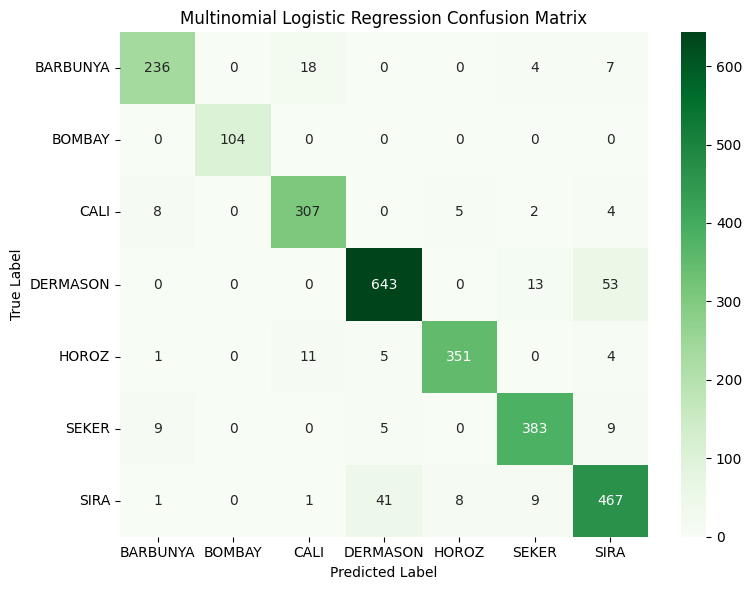

In [ ]:
logreg_report = pd.DataFrame(
    classification_report(
        y_test,
        logreg_test_predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )
).transpose()

display(logreg_report)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, logreg_test_predictions),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Multinomial Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**Interpretation**
- Slight improvement over KNN (~92% accuracy) with more balanced predictions.
- Still shows confusion between SIRA and DERMASON, though slightly reduced.
- Fewer mix-ups overall, especially for HOROZ and SEKER.
- BOMBAY remains perfectly predicted again.
- Performs more consistently, but as a linear model, it still struggles with overlapping classes.

### 3. Neural Network Error Analysis

Finally, the neural network predictions are analyzed to identify where the nonlinear model improves class separation and where errors remain.

,precision,recall,f1-score,support
BARBUNYA,0.916981,0.916981,0.916981,265.000000
BOMBAY,1.000000,1.000000,1.000000,104.000000
CALI,0.933131,0.941718,0.937405,326.000000
DERMASON,0.919220,0.930889,0.925018,709.000000
HOROZ,0.958791,0.938172,0.948370,372.000000
SEKER,0.934783,0.953202,0.943902,406.000000
SIRA,0.885437,0.865275,0.875240,527.000000
accuracy,0.925065,0.925065,0.925065,0.925065
macro avg,0.935478,0.935177,0.935274,2709.000000
weighted avg,0.924970,0.925065,0.924954,2709.000000


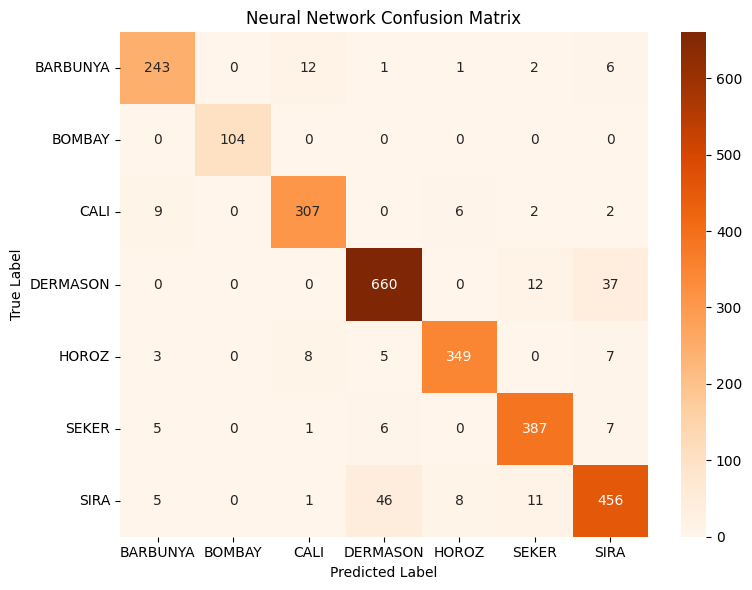

In [32]:
mlp_report = pd.DataFrame(
    classification_report(
        y_test,
        mlp_test_predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )
).transpose()

display(mlp_report)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, mlp_test_predictions),
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**Interpretation**
- Best overall performance 92.5%
- Reduces errors most classes: BARBUNYA vs CALI
- SIRA is still the most confusing class.
- Learns more complex patterns, but can’t fully resolve very similar classes.

In [33]:
# Consolidate macro/weighted metrics and identify weakest classes per model
error_reports = [
    ("K-Nearest Neighbors", knn_report),
    ("Multinomial Logistic Regression", logreg_report),
    ("Neural Network", mlp_report),
]

summary_rows = []
class_labels = list(label_encoder.classes_)

for model_name, report in error_reports:
    per_class_recalls = report.loc[class_labels, "recall"]
    lowest_class = per_class_recalls.idxmin()
    summary_rows.append({
        "Model": model_name,
        "Macro F1": report.loc["macro avg", "f1-score"],
        "Weighted F1": report.loc["weighted avg", "f1-score"],
        "Lowest-Recall Class": lowest_class,
        "Lowest Recall": per_class_recalls.loc[lowest_class],
        "Highest-Recall Class": per_class_recalls.idxmax(),
        "Highest Recall": per_class_recalls.max(),
    })

error_summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values(by="Macro F1", ascending=False)
    .reset_index(drop=True)
)

error_summary_df

,Model,Macro F1,Weighted F1,Lowest-Recall Class,Lowest Recall,Highest-Recall Class,Highest Recall
0,Neural Network,0.935274,0.924954,SIRA,0.865275,BOMBAY,1.0
1,Multinomial Logistic Regression,0.930551,0.919667,SIRA,0.886148,BOMBAY,1.0
2,K-Nearest Neighbors,0.927027,0.915652,SIRA,0.874763,BOMBAY,1.0


### Cross-Model Takeaways and Remediation Plan
- Across all models, the macro F1 slightly lower than the weighted F1, which tells us the models are but still struggling with a few specific classes such as SIRA, BARBUNYA, and DERMASON.
- BOMBAY is the easiest to classify, while SIRA is the hardest to classify consistently. 
- To improve performance, a few adjustments that will be applied to directly address the confusing classes the models are struggling with will be disccused and explored in the Model Tuning section. 

---
## **Model Tuning**

Hyperparameter tuning is performed to improve the baseline models. Grid search with cross-validation is used so that each classifier is optimized using the same training data in a more systematic way.

In [34]:
tuned_models = {}
tuning_results = []

### 1. K-Nearest Neighbors Tuning

For KNN, the number of neighbors, distance metric, and weighting scheme are tuned because these directly affect how similarity is measured during prediction.

In [35]:
knn_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
knn_search.fit(X_train_scaled, y_train)

tuned_models["K-Nearest Neighbors"] = knn_search.best_estimator_
knn_tuned_predictions = knn_search.best_estimator_.predict(X_test_scaled)

tuning_results.append({
    "Model": "K-Nearest Neighbors",
    "Best Parameters": knn_search.best_params_,
    "CV Accuracy": knn_search.best_score_,
    "Test Accuracy": accuracy_score(y_test, knn_tuned_predictions)
})

print("Best Parameters:", knn_search.best_params_)
print("Best CV Accuracy:", round(knn_search.best_score_, 4))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best CV Accuracy: 0.9248


### 2. Multinomial Logistic Regression Tuning

For logistic regression, the regularization strength is tuned to balance underfitting and overfitting while retaining a multinomial setup.

In [36]:
logreg_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "newton-cg"]
}

logreg_search = GridSearchCV(
    estimator=LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ),
    param_grid=logreg_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
logreg_search.fit(X_train_scaled, y_train)

tuned_models["Multinomial Logistic Regression"] = logreg_search.best_estimator_
logreg_tuned_predictions = logreg_search.best_estimator_.predict(X_test_scaled)

tuning_results.append({
    "Model": "Multinomial Logistic Regression",
    "Best Parameters": logreg_search.best_params_,
    "CV Accuracy": logreg_search.best_score_,
    "Test Accuracy": accuracy_score(y_test, logreg_tuned_predictions)
})

print("Best Parameters:", logreg_search.best_params_)
print("Best CV Accuracy:", round(logreg_search.best_score_, 4))

Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best CV Accuracy: 0.9249


c:\Users\fonte\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 3. Neural Network Tuning

For the neural network, the hidden-layer structure and regularization term are tuned to explore whether a different architecture yields better generalization.

In [37]:
mlp_grid = {
    "hidden_layer_sizes": [(64,), (64, 32), (128, 64)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

mlp_search = GridSearchCV(
    estimator=MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ),
    param_grid=mlp_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
mlp_search.fit(X_train_scaled, y_train)

tuned_models["Neural Network"] = mlp_search.best_estimator_
mlp_tuned_predictions = mlp_search.best_estimator_.predict(X_test_scaled)

tuning_results.append({
    "Model": "Neural Network",
    "Best Parameters": mlp_search.best_params_,
    "CV Accuracy": mlp_search.best_score_,
    "Test Accuracy": accuracy_score(y_test, mlp_tuned_predictions)
})

print("Best Parameters:", mlp_search.best_params_)
print("Best CV Accuracy:", round(mlp_search.best_score_, 4))

Best Parameters: {'alpha': 0.01, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.01}
Best CV Accuracy: 0.9335


#### Tuning Summary

The table below compares the tuned versions of the three models using both cross-validation accuracy and test accuracy.

In [38]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

tuning_results_df

,Model,Best Parameters,CV Accuracy,Test Accuracy
0,Neural Network,"{'alpha': 0.01, 'hidden_layer_sizes': (64,), '...",0.933543,0.924326
1,Multinomial Logistic Regression,"{'C': 10, 'solver': 'lbfgs'}",0.924866,0.921004
2,K-Nearest Neighbors,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",0.924774,0.915836


---
## **Model Evaluation**

This section evaluates the tuned versions of the models on the test set. The goal is to compare the final classifiers after hyperparameter tuning and identify the strongest overall performer.

### 1. K-Nearest Neighbors Evaluation

The tuned KNN model is evaluated using its final test-set accuracy and a detailed classification report.

In [39]:
print("K-Nearest Neighbors Test Accuracy:", round(accuracy_score(y_test, knn_tuned_predictions), 4))
display(pd.DataFrame(
    classification_report(
        y_test,
        knn_tuned_predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )
).transpose())

K-Nearest Neighbors Test Accuracy: 0.9158


,precision,recall,f1-score,support
BARBUNYA,0.943548,0.883019,0.912281,265.000000
BOMBAY,1.000000,1.000000,1.000000,104.000000
CALI,0.903509,0.947853,0.925150,326.000000
DERMASON,0.916549,0.913963,0.915254,709.000000
HOROZ,0.961111,0.930108,0.945355,372.000000
SEKER,0.936275,0.940887,0.938575,406.000000
SIRA,0.848148,0.869070,0.858482,527.000000
accuracy,0.915836,0.915836,0.915836,0.915836
macro avg,0.929877,0.926414,0.927871,2709.000000
weighted avg,0.916594,0.915836,0.915992,2709.000000


### 2. Multinomial Logistic Regression Evaluation

The tuned logistic regression model is evaluated next to determine how well the optimized linear classifier performs on unseen data.

In [40]:
print("Multinomial Logistic Regression Test Accuracy:", round(accuracy_score(y_test, logreg_tuned_predictions), 4))
display(pd.DataFrame(
    classification_report(
        y_test,
        logreg_tuned_predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )
).transpose())

Multinomial Logistic Regression Test Accuracy: 0.921


,precision,recall,f1-score,support
BARBUNYA,0.929412,0.894340,0.911538,265.000000
BOMBAY,1.000000,0.990385,0.995169,104.000000
CALI,0.905605,0.941718,0.923308,326.000000
DERMASON,0.925395,0.909732,0.917496,709.000000
HOROZ,0.969529,0.940860,0.954980,372.000000
SEKER,0.936740,0.948276,0.942472,406.000000
SIRA,0.861878,0.888046,0.874766,527.000000
accuracy,0.921004,0.921004,0.921004,0.921004
macro avg,0.932651,0.930479,0.931390,2709.000000
weighted avg,0.921675,0.921004,0.921173,2709.000000


### 3. Neural Network Evaluation

The tuned neural network is evaluated last to see whether its optimized nonlinear structure produces the best final performance.

In [41]:
print("Neural Network Test Accuracy:", round(accuracy_score(y_test, mlp_tuned_predictions), 4))
display(pd.DataFrame(
    classification_report(
        y_test,
        mlp_tuned_predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )
).transpose())

Neural Network Test Accuracy: 0.9243


,precision,recall,f1-score,support
BARBUNYA,0.940711,0.898113,0.918919,265.000000
BOMBAY,1.000000,1.000000,1.000000,104.000000
CALI,0.927492,0.941718,0.934551,326.000000
DERMASON,0.925501,0.911142,0.918266,709.000000
HOROZ,0.959459,0.954301,0.956873,372.000000
SEKER,0.933014,0.960591,0.946602,406.000000
SIRA,0.867290,0.880455,0.873823,527.000000
accuracy,0.924326,0.924326,0.924326,0.924326
macro avg,0.936210,0.935189,0.935576,2709.000000
weighted avg,0.924554,0.924326,0.924330,2709.000000


#### Final Comparison

The tuned models are compared one last time to identify the best classifier based on test accuracy.

In [42]:
final_results_df = tuning_results_df[["Model", "CV Accuracy", "Test Accuracy"]].copy()
best_model_name = final_results_df.iloc[0]["Model"]

display(final_results_df)
print("Best tuned model:", best_model_name)

,Model,CV Accuracy,Test Accuracy
0,Neural Network,0.933543,0.924326
1,Multinomial Logistic Regression,0.924866,0.921004
2,K-Nearest Neighbors,0.924774,0.915836


Best tuned model: Neural Network


---
## **Insights and Conclusions**

The results show that all three selected models performed well on the dry bean classification task, with test accuracies above 91%. Among the tuned models, the Neural Network achieved the best overall performance with a cross-validation accuracy of 0.9335 and a test accuracy of 0.9243. This indicates that the nonlinear relationships among the bean measurements were useful for classification, and that the neural network was the most effective model at capturing them.

The Multinomial Logistic Regression model ranked second with a test accuracy of 0.9210, only slightly below the neural network. This is an important result because it shows that a simpler linear model can already classify the bean varieties very well after feature scaling. The K-Nearest Neighbors model performed slightly lower at 0.9158, but it still produced competitive results and remained a strong baseline for comparison.

The evaluation repots suggest that the BOMBAY class was the easiest to identify, with almost perfect precision, recall, and F1-score across all models used. This likely means its feature values are more distinct from the other bean varieties. On the other hand, the SIRA class was the hardest to identify, with the lowest F1-scores across all three models, while BARBUNYA and DERMASON also showed slightly lower recall than the stronger-performing classes. We can infer that some bean classes share overlapping size and shape characteristics, making them harder to separate perfectly.

The tuning results also show that hyperparameter optimization provided little to no gains. Logistic Regression improved slightly after tuning, KNN changed only marginally, and the tuned Neural Network remained the best final model overall. This suggests that the dataset is already highly learnable with the chosen features, and large performance jumps are unlikely without trying more advanced feature engineering, stronger neural-network tuning, or ensemble methods.

In conclusion, the project demonstrates that morphological bean measurements are highly informative for multiclass classification. The neural network peformed the best out of all the other models for this notebook because it achieved the best overall accuracy and the best macro-level performance. Other models, like the logistic regression model, performed relatively well with nearly comparable accuracy. Future work may focus on deeper error analysis for difficult classes, as well as expanded tuning or ensemble modeling to improve class separation further.

---
## References